In [24]:
from __future__ import annotations

import hashlib
import re
from pathlib import Path
from typing import Iterable
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib.legend import Legend
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
import os
import platform

def setup_chinese_font():
    system = platform.system()
    if system == 'Windows':
        # Windows 优先使用微软雅黑，SimHei 作为备选
        fonts = ['Microsoft YaHei', 'SimHei', 'KaiTi']
    elif system == 'Darwin': # macOS
        # macOS 使用苹方或华文黑体
        fonts = ['PingFang HK', 'PingFang SC', 'Arial Unicode MS', 'Heiti TC']
    else:
        # Linux 使用文泉驿
        fonts = ['WenQuanYi Zen Hei', 'Noto Sans CJK']
    
    # 设置全局无衬线字体
    plt.rcParams['font.sans-serif'] = fonts
    # 解决负号显示为方块的问题
    plt.rcParams['axes.unicode_minus'] = False

# 执行字体设置
setup_chinese_font()
science_colors = [
    '#0C5DA5', '#00B945', '#FF9500', '#FF2C00', 
    '#845B97', '#474747', '#9e9e9e'
]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=science_colors)
sns.set_palette(science_colors)

def find_project_root(start: Path) -> Path:
    """Walk upwards until Processed_Data exists."""
    cur = start.resolve()
    for _ in range(12):
        if (cur / "Processed_Data").exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start.resolve()

def safe_filename(name: str) -> str:
    """ASCII-friendly, stable, and unique for Chinese metric names."""
    raw = name.strip()
    normalized = re.sub(r"[\/:\s]+", "_", raw)
    ascii_part = re.sub(r"[^A-Za-z0-9_]+", "", normalized)
    h = hashlib.md5(raw.encode("utf-8")).hexdigest()[:8]
    return f"{ascii_part}_{h}" if ascii_part else f"metric_{h}"


In [25]:
# 这次的图表都放在 Deliverables/Mid-Term文件夹里面
ROOT = find_project_root(Path.cwd())
ANALYSIS_DIR = os.path.join(ROOT, "Analysis")
DATA_DIR = os.path.join(ROOT, "Data")
PROCESSED_DATA_DIR = os.path.join(ROOT, "Processed_Data")
DELIVERABLES_DIR = os.path.join(ROOT, "Deliverables")
MID_TERM_DIR = os.path.join(DELIVERABLES_DIR, "Mid-Term") # 中期文件夹
MID_TERM_CHARTS_DIR = os.path.join(MID_TERM_DIR, "Charts") # 中期图表文件夹
os.makedirs(ANALYSIS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(DELIVERABLES_DIR, exist_ok=True)
os.makedirs(MID_TERM_DIR, exist_ok=True)
os.makedirs(MID_TERM_CHARTS_DIR, exist_ok=True)

In [26]:
# 读取主表
INPUT_EXCEL = os.path.join(PROCESSED_DATA_DIR, "k7_inner_merged_df.xlsx")
df = pd.read_excel(INPUT_EXCEL)
# 爆款筛选门槛
FILTER_METRICS = ['3秒播放率','5秒播放率','10秒播放率','整体展现次数','整体点击次数',]
thresholds = {'3秒播放率': 40.0,'5秒播放率': 35.0,'10秒播放率': 30.0,'整体展现次数': 2800.0,'整体点击次数': 200.0,}
for c in FILTER_METRICS:
    df[c] = pd.to_numeric(df[c], errors='coerce')
mask = np.ones(len(df), dtype=bool)
for c in FILTER_METRICS:
    thr = float(thresholds.get(c, 0.0))
    mask &= (df[c].to_numpy() >= thr)
df["is_popular"] = mask.astype(int)

# 统计爆款
display(df.head(3))
print("rows:", len(df), "cols:", df.shape[1])
print(f"爆款比例: {df['is_popular'].sum()} / {len(df)} ({df['is_popular'].mean():.2%})")

# 转化label
if "is_popular" not in df.columns:
    raise ValueError("Expected column `is_popular` in merged table.")
df["is_popular"] = pd.to_numeric(df["is_popular"], errors="coerce").fillna(0).astype(int)
df["is_popular_label"] = df["is_popular"].map({0: "非爆款", 1: "爆款"}).fillna("未知")
print("is_popular value counts:")
display(df["is_popular"].value_counts(dropna=False))

# 新的没有source列了, 我在数据处理的时候把声深未来和金运声音研所的数据进行average了
# if "source" in df.columns:
#     print("source x is_popular_label:")
#     display(pd.crosstab(df["source"], df["is_popular_label"]))

print(f"Columns: {df.columns.tolist()}")

,素材ID,素材名称,素材创建时间,level_1_folder,level_2_folder,video_file,video_path,素材时长,净成交ROI,整体支付ROI,...,整体转化率,5秒播放率,2秒播放率,3秒播放率,10秒播放率,视频完播率,净成交金额结算率,净成交订单结算率,1小时内退款率,is_popular
0,7550524038641270820,9月15日-K7-CM- (1)已发.mp4,2026-01-12 11:35:25,9月份,9.15,9月15日-K7-CM- (1)已发.mp4,F:\KINYO\K7素材汇总\9月份\9.15\9月15日-K7-CM- (1)已发.mp4,102,6.93,6.93,...,1.47,43.95,58.56,52.13,42.42,17.01,NaN,NaN,NaN,0
1,7550860226751119411,9月16日-K7-CM- (1)已发.mp4,2026-01-12 11:35:25,9月份,9.16,9月16日-K7-CM- (1)已发.mp4,F:\KINYO\K7素材汇总\9月份\9.16\9月16日-K7-CM- (1)已发.mp4,91,0.00,0.00,...,0.00,35.71,64.29,57.14,7.14,0.00,NaN,NaN,NaN,0
2,7550860349243834409,9月15日-K7-CM- (2)已发.mp4,2026-01-12 11:35:25,9月份,9.15,9月15日-K7-CM- (2)已发.mp4,F:\KINYO\K7素材汇总\9月份\9.15\9月15日-K7-CM- (2)已发.mp4,90,0.00,0.00,...,0.00,100.00,100.00,100.00,100.00,0.00,NaN,NaN,NaN,0


rows: 1742 cols: 46
爆款比例: 193 / 1742 (11.08%)
is_popular value counts:


0    1549
1     193
Name: is_popular, dtype: int64

Columns: ['素材ID', '素材名称', '素材创建时间', 'level_1_folder', 'level_2_folder', 'video_file', 'video_path', '素材时长', '净成交ROI', '整体支付ROI', '整体展现次数', '整体点击次数', '整体点击单价', '整体千次展现费用', '视频评论数', '视频播放数', '新增粉丝数', '视频点赞数', '平均观看时长', '整体消耗', '基础消耗', '整体成交金额', '整体成交订单数', '整体成交订单成本', '用户实际支付金额', '智能优惠券金额', '电商平台补贴金额', '整体未完结预售订单预估金额', '净成交金额', '净成交订单数', '净成交订单成本', '用户实际支付净成交金额', '智能优惠券未退款金额', '电商平台补贴未退款金额', '1小时内退款订单数', '整体点击率', '整体转化率', '5秒播放率', '2秒播放率', '3秒播放率', '10秒播放率', '视频完播率', '净成交金额结算率', '净成交订单结算率', '1小时内退款率', 'is_popular', 'is_popular_label']


In [27]:
def coerce_numeric(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return s
    s2 = s.astype(str).str.strip()
    s2 = s2.replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    s2 = s2.str.replace(",", "", regex=False)
    pct_mask = s2.str.endswith("%", na=False)
    s_num = pd.to_numeric(s2.str.replace("%", "", regex=False), errors="coerce")
    s_num[pct_mask] = s_num[pct_mask] / 100.0
    return s_num

def available_cols(df: pd.DataFrame, cols: Iterable[str]) -> list[str]:
    return [c for c in cols if c in df.columns]

# 有部分列存在大量的缺失值，因为声深未来和金运声研所的指标不是完全一致的，第一阶段先针对视频进行分析，后续再对转化率等等指标分析
label_metrics = []
validate_metrics = [
    '素材时长', '净成交ROI', '整体支付ROI', '整体展现次数', '整体点击次数', 
    '整体点击单价', '整体千次展现费用', '视频评论数', '视频播放数', 
    '新增粉丝数', '视频点赞数', '平均观看时长', '整体点击率', 
    '整体转化率', '5秒播放率', '2秒播放率', '3秒播放率', '10秒播放率', '视频完播率'
]

metrics = available_cols(df, label_metrics + validate_metrics)
print("metrics used:", metrics)

for c in metrics:
    df[c] = coerce_numeric(df[c])

display(df[["is_popular_label"] + metrics].head(3))

metrics used: ['素材时长', '净成交ROI', '整体支付ROI', '整体展现次数', '整体点击次数', '整体点击单价', '整体千次展现费用', '视频评论数', '视频播放数', '新增粉丝数', '视频点赞数', '平均观看时长', '整体点击率', '整体转化率', '5秒播放率', '2秒播放率', '3秒播放率', '10秒播放率', '视频完播率']


,is_popular_label,素材时长,净成交ROI,整体支付ROI,整体展现次数,整体点击次数,整体点击单价,整体千次展现费用,视频评论数,视频播放数,新增粉丝数,视频点赞数,平均观看时长,整体点击率,整体转化率,5秒播放率,2秒播放率,3秒播放率,10秒播放率,视频完播率
0,非爆款,102,6.93,6.93,998.0,68.0,1.91,130.06,0.0,917.0,0.0,0.0,10.66,6.81,1.47,43.95,58.56,52.13,42.42,17.01
1,非爆款,91,0.00,0.00,23.0,5.0,0.44,96.52,0.0,14.0,0.0,0.0,5.67,21.74,0.00,35.71,64.29,57.14,7.14,0.00
2,非爆款,90,0.00,0.00,1.0,0.0,0.00,390.00,0.0,1.0,0.0,0.0,0.00,0.00,0.00,100.00,100.00,100.00,100.00,0.00


In [28]:
def describe_by_group(df: pd.DataFrame, group_cols: list[str], metrics: list[str]) -> pd.DataFrame:
    rows = []
    for m in metrics:
        x = df[group_cols + [m]].dropna(subset=[m])
        def q(p: float):
            return lambda s: s.quantile(p)
        agg = x.groupby(group_cols)[m].agg(
            count="count",
            mean="mean",
            median="median",
            q25=q(0.25),
            q75=q(0.75),
            min="min",
            max="max",
        )
        agg.insert(0, "metric", m)
        rows.append(agg.reset_index())
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

overall_stats = describe_by_group(df, ["is_popular"], metrics)
overall_stats_renamed = overall_stats.rename(columns = {original_col: (" ".join(original_col.split("_"))).capitalize() for original_col in overall_stats.columns})
display(overall_stats_renamed.head(30))
overall_stats_renamed.to_excel(os.path.join(PROCESSED_DATA_DIR, "overall_stats_week4.xlsx"), index=False)

,Is popular,Metric,Count,Mean,Median,Q25,Q75,Min,Max
0,0,素材时长,1549,166.024532,188.000,96.000,213.000,31.000,299.000
1,1,素材时长,193,216.336788,214.000,194.000,233.000,91.000,298.000
2,0,净成交ROI,1549,3.805539,1.380,0.000,3.670,0.000,1341.790
3,1,净成交ROI,193,2.800026,2.580,1.985,3.195,0.440,11.675
4,0,整体支付ROI,1549,4.301924,1.825,0.000,4.440,0.000,1341.790
5,1,整体支付ROI,193,3.287047,3.155,2.455,3.855,0.705,11.675
6,0,整体展现次数,1549,18706.085216,930.000,277.000,3387.000,0.000,6226514.000
7,1,整体展现次数,193,61952.670984,13163.000,6646.000,38053.500,2897.000,3200623.500
8,0,整体点击次数,1549,688.878309,67.500,22.000,194.500,0.000,178289.000
9,1,整体点击次数,193,2825.106218,626.500,364.500,1872.000,201.500,126873.500


In [29]:
# # 没有source了
# if "source" in df.columns:
#     by_source_stats = describe_by_group(df, ["source", "is_popular"], metrics)
#     display(by_source_stats.head(30))
# else:
#     by_source_stats = pd.DataFrame()
#     print("No `source` column; skip.")

In [30]:
# 简单效应汇总：爆款 vs 非爆款（均值/中位数比值）
def effect_summary(overall_stats: pd.DataFrame) -> pd.DataFrame:
    if overall_stats.empty or "is_popular" not in overall_stats.columns:
        return overall_stats
    
    base = overall_stats.pivot_table(
        index="metric",
        columns="is_popular",
        values=["count", "mean", "median", "q25", "q75"],
        aggfunc="first",
    )
    
    base.columns = [f"{a}_{'popular' if b == 1 else 'non_popular'}" for a, b in base.columns]
    base = base.reset_index()

    def add_diff_ratio(name: str) -> None:
        a = f"{name}_popular"
        b = f"{name}_non_popular"
        if a in base.columns and b in base.columns:
            num = pd.to_numeric(base[a], errors="coerce")
            denom_raw = pd.to_numeric(base[b], errors="coerce")
            denom = denom_raw.mask(denom_raw == 0)
            base[f"{name}_diff"] = num - denom_raw
            base[f"{name}_ratio"] = num / denom

    add_diff_ratio("mean")
    add_diff_ratio("median")
    add_diff_ratio("q75")
    return base

effects = effect_summary(overall_stats)
effects_small = effects[effects["metric"].isin(available_cols(df, validate_metrics))].copy()
keep_cols = [
    "metric",
    "median_non_popular", "median_popular", "median_ratio",
    "mean_non_popular", "mean_popular", "mean_ratio",
]
keep_cols = [c for c in keep_cols if c in effects_small.columns]
effects_small = effects_small[keep_cols]
for c in ["median_ratio", "mean_ratio", "median_non_popular", "median_popular", "mean_non_popular", "mean_popular"]:
    if c in effects_small.columns:
        effects_small[c] = pd.to_numeric(effects_small[c], errors="coerce").round(3)
effects_small_renamed = effects_small.rename(columns = {original_col: (" ".join(original_col.split("_"))).capitalize() for original_col in effects_small.columns})
display(effects_small_renamed)
effects_small_renamed.to_excel(os.path.join(PROCESSED_DATA_DIR, "effects_summary_week4.xlsx"), index=False)


,Metric,Median non popular,Median popular,Median ratio,Mean non popular,Mean popular,Mean ratio
0,10秒播放率,30.340,37.700,1.243,31.875,38.505,1.208
1,2秒播放率,51.720,64.700,1.251,52.346,66.638,1.273
2,3秒播放率,43.115,56.480,1.310,44.310,60.636,1.368
3,5秒播放率,34.575,48.885,1.414,36.154,53.499,1.480
4,净成交ROI,1.380,2.580,1.870,3.806,2.800,0.736
5,平均观看时长,8.520,16.765,1.968,10.657,17.260,1.620
6,整体千次展现费用,149.265,179.710,1.204,160.890,195.292,1.214
7,整体展现次数,930.000,13163.000,14.154,18706.085,61952.671,3.312
8,整体支付ROI,1.825,3.155,1.729,4.302,3.287,0.764
9,整体点击单价,2.205,3.355,1.522,2.526,3.824,1.514


In [31]:
# ==========================================
# 自定义图例处理器
# ==========================================
class BoxWithMedianHandler(HandlerBase):
    """自定义图例处理器：绘制带中位线的箱体图形"""
    
    def __init__(self, color='blue', is_dark=False, **kwargs):
        super().__init__(**kwargs)
        self.color = color
        # 根据背景深浅决定中位线颜色
        self.line_color = 'white' if is_dark else 'black'
    
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        # 创建矩形（箱体）
        rect = Rectangle(
            (xdescent, ydescent),
            width, height,
            facecolor=self.color,
            edgecolor='black',
            alpha=0.7,
            linewidth=1.5,
            transform=trans
        )
        
        # 创建中位线
        median_y = ydescent + height * 0.5
        median_line = Line2D(
            [xdescent, xdescent + width],
            [median_y, median_y],
            color=self.line_color,
            linewidth=2.5,
            solid_capstyle='butt',
            transform=trans
        )
        
        return [rect, median_line]

# ==========================================
# 绘图主函数
# ==========================================
def plot_metric(df, metric: str, log1p: bool = False, safe_filename_func=None) -> None:
    """
    增加了 df 和 safe_filename_func 参数，方便外部调用
    """
    # 简单的文件名处理函数（如果外部没传）
    if safe_filename_func is None:
        safe_filename_func = lambda x: x.replace(" ", "_").replace("/", "_")

    if metric not in df.columns:
        print(f"skip: missing column {metric}")
        return
    
    # 数据清洗
    plot_df = df[["is_popular_label", metric]].dropna(subset=[metric]).copy()
    if plot_df.empty:
        print(f"skip: empty after dropna for {metric}")
        return

    safe = safe_filename_func(metric)
    if not os.path.exists(MID_TERM_CHARTS_DIR):
        os.makedirs(MID_TERM_CHARTS_DIR)
        
    box_path = os.path.join(MID_TERM_CHARTS_DIR, f"box_{safe}.png")
    bar_path = os.path.join(MID_TERM_CHARTS_DIR, f"bar_{safe}.png")

    order = ["非爆款", "爆款"]
    palette = ['#0C5DA5', '#FF9500']

    # --- 数据预处理 ---
    y_label = metric
    plot_df["_y"] = pd.to_numeric(plot_df[metric], errors="coerce")
    if log1p:
        plot_df["_y"] = np.log1p(plot_df["_y"].clip(lower=0))
        y_label = f"log1p({metric})"
    
    plot_df = plot_df.dropna(subset=["_y"])
    if plot_df.empty:
        print(f"skip: empty after numeric/log transform for {metric}")
        return

    def fmt(v: float) -> str:
        if pd.isna(v): return "NA"
        v = float(v)
        if abs(v) >= 1000 or (0 < abs(v) < 0.01): return f"{v:.2g}"
        return f"{v:.3f}"

    # ==========================================
    # 1. 箱线图 (Boxplot)
    # ==========================================
    plt.figure(figsize=(8.5, 5))
    
    ax = sns.boxplot(
        data=plot_df,
        x="is_popular_label",
        y="_y",
        hue="is_popular_label",
        order=order,
        showfliers=False,
        palette=palette,
        legend=False      # 关闭默认图例
    )
    
    ax.set_xlabel("")
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(f"{metric} 分布对比（箱线图）", fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # --- 构建自定义图例 ---
    legend_handles = []
    legend_labels = []
    handler_map = {} # 初始化映射字典

    for i, grp in enumerate(order):
        grp_data = plot_df[plot_df["is_popular_label"] == grp]["_y"]
        if grp_data.empty: continue
        
        # 计算统计值
        q1, median, q3 = grp_data.quantile([0.25, 0.5, 0.75])
        iqr = q3 - q1
        color = palette[i]
        is_dark = (i == 0)  # 蓝色背景深，用白线
        
        # 创建一个“占位”对象用于图例
        handle = Rectangle((0, 0), 1, 1, facecolor=color)
        
        # 构建多行文本标签
        stats_text = (
            f"{grp}\n"
            f"┌─────────────┐\n"
            f"-- Q1:  {fmt(q1):>16} \n"
            f"-- Med: {fmt(median):>14} \n"
            f"-- Q3:  {fmt(q3):>16} \n"
            f"-- IQR: {fmt(iqr):>16} \n"
            f"└─────────────┘"
        )
        
        legend_handles.append(handle)
        legend_labels.append(stats_text)
        
        # 关键修正：直接在循环中建立 handle 到 Handler 的映射
        handler_map[handle] = BoxWithMedianHandler(color=color, is_dark=is_dark)
    
    # 添加图例
    legend = ax.legend(
        legend_handles,
        legend_labels,
        title="## 统计摘要 ##",
        loc='center left',
        bbox_to_anchor=(1, 0.5),
        frameon=True,
        shadow=True,
        fancybox=True,
        framealpha=0.95,
        handler_map=handler_map, # 传入构建好的映射
        prop={'size': 9,'family': 'sans-serif'} 
    )
    
    legend.get_title().set_fontweight('bold')
    legend.get_title().set_fontsize(10)
    
    plt.tight_layout()
    plt.savefig(box_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

    # ==========================================
    # 2. 柱状图 (Barplot)
    # ==========================================
    agg = plot_df.groupby("is_popular_label")["_y"].agg(mean="mean", median="median").reindex(order)
    agg = agg.reset_index()
    melted = agg.melt(id_vars="is_popular_label", var_name="stat", value_name="value")
    melted["stat"] = melted["stat"].apply(lambda s: s.capitalize())
    
    plt.figure(figsize=(7, 4.5))
    ax = sns.barplot(
        data=melted,
        x="is_popular_label",
        y="value",
        hue="stat",
        order=order,
        palette=palette,
    )
    
    ax.set_xlabel("")
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(f"{metric} 均值/中位数对比（柱状图）", fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    for container in ax.containers:
        ax.bar_label(container, label_type='center', fmt='%.3f', 
                    fontsize=9, fontweight='bold', padding=2)
    
    plt.legend(title='统计量', loc='upper right', frameon=True, shadow=True)
    # plt.tight_layout()
    plt.savefig(bar_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

    print("saved:", box_path)
    print("saved:", bar_path)

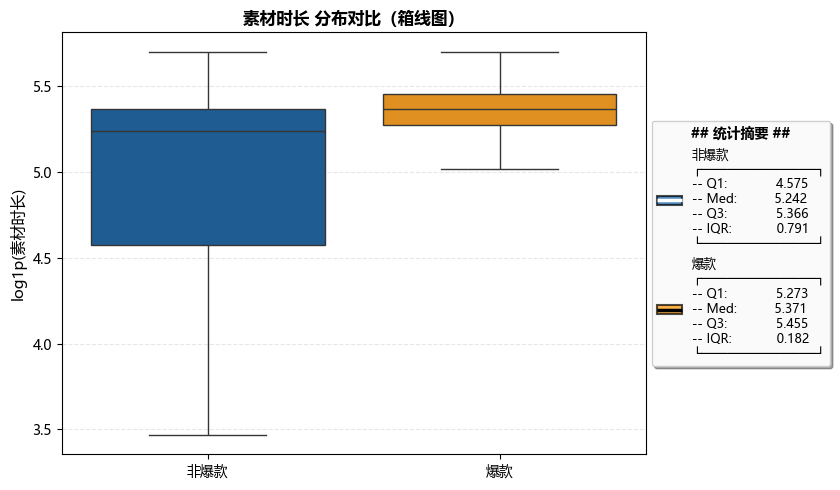

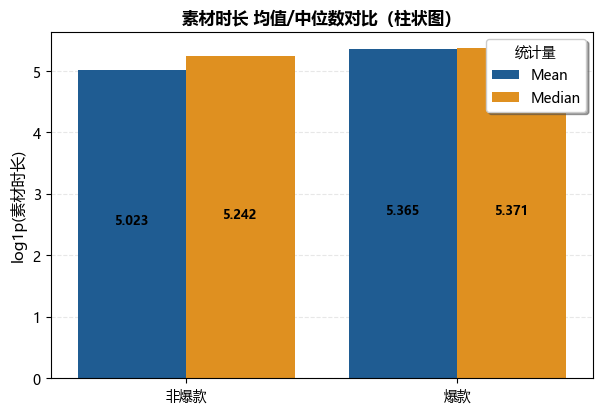

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_素材时长.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_素材时长.png


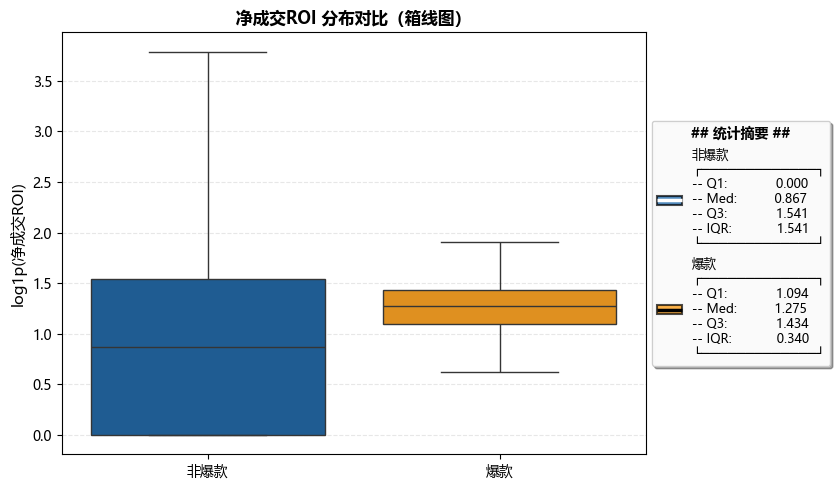

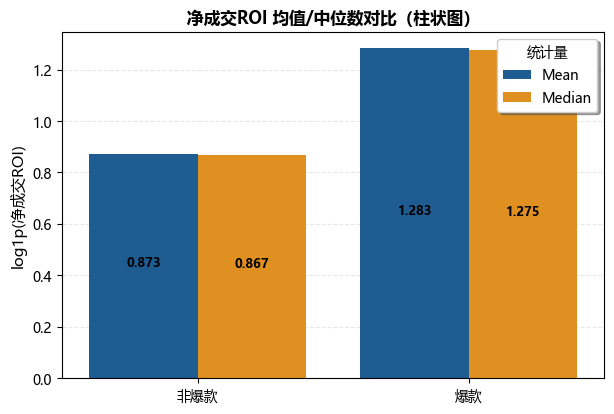

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_净成交ROI.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_净成交ROI.png


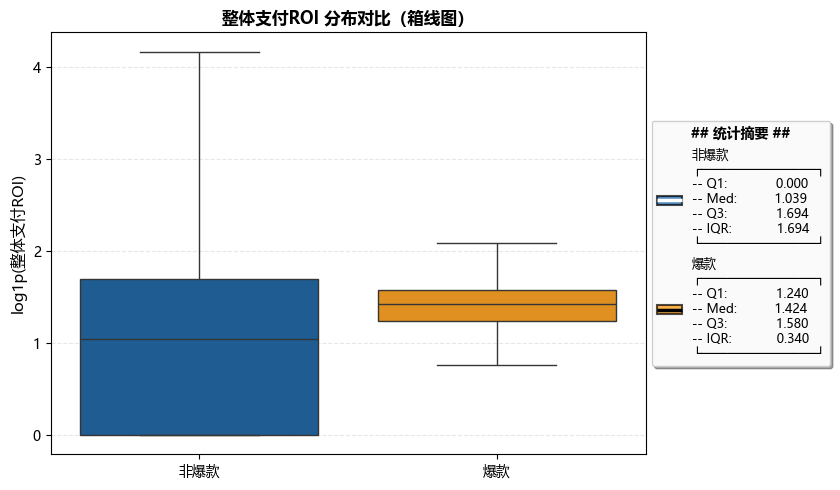

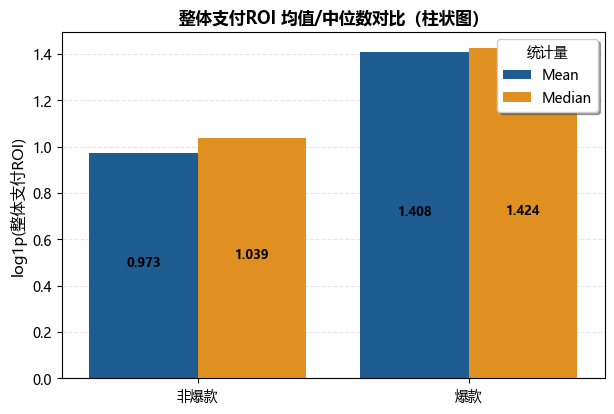

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_整体支付ROI.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_整体支付ROI.png


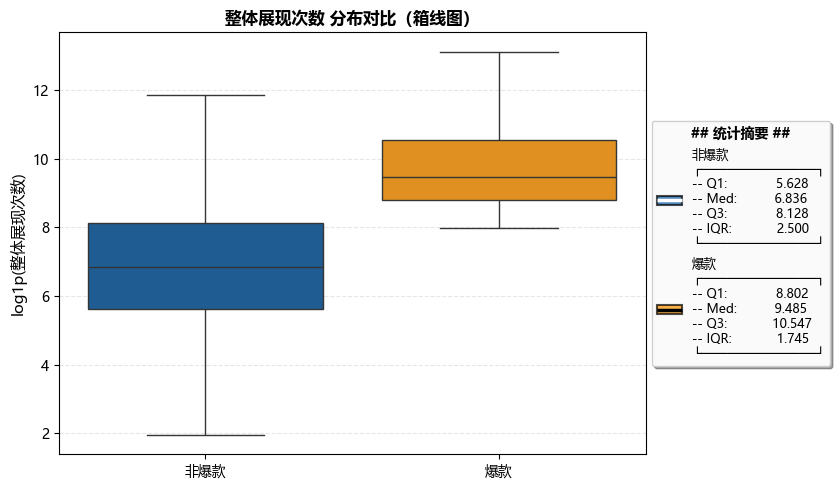

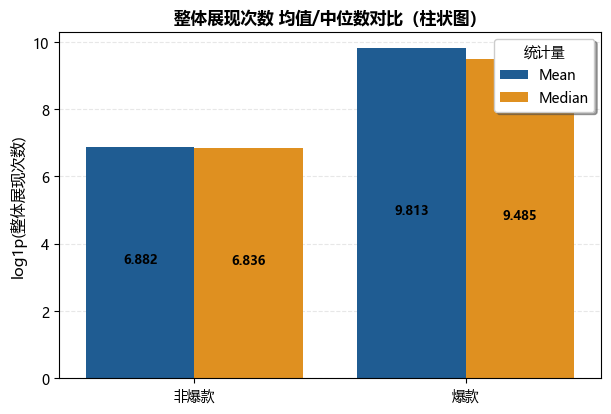

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_整体展现次数.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_整体展现次数.png


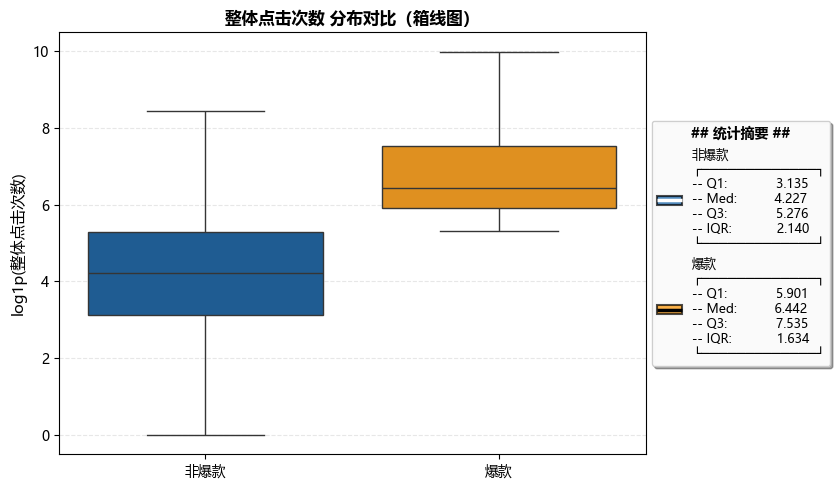

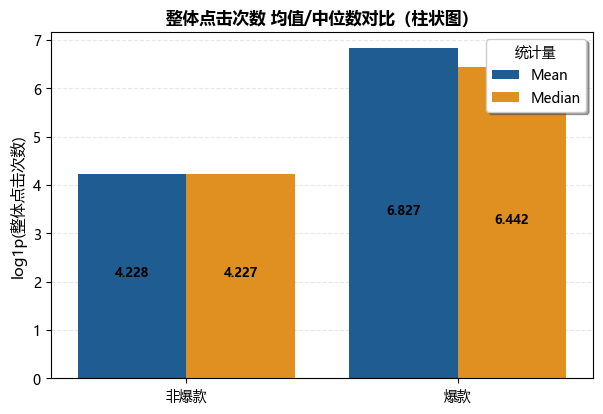

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_整体点击次数.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_整体点击次数.png


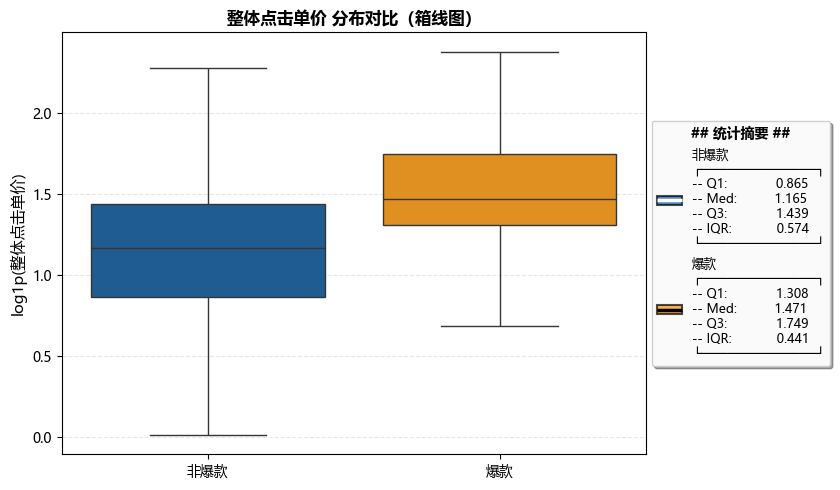

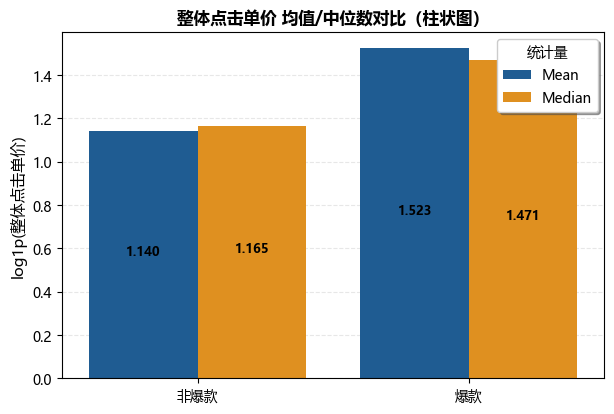

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_整体点击单价.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_整体点击单价.png


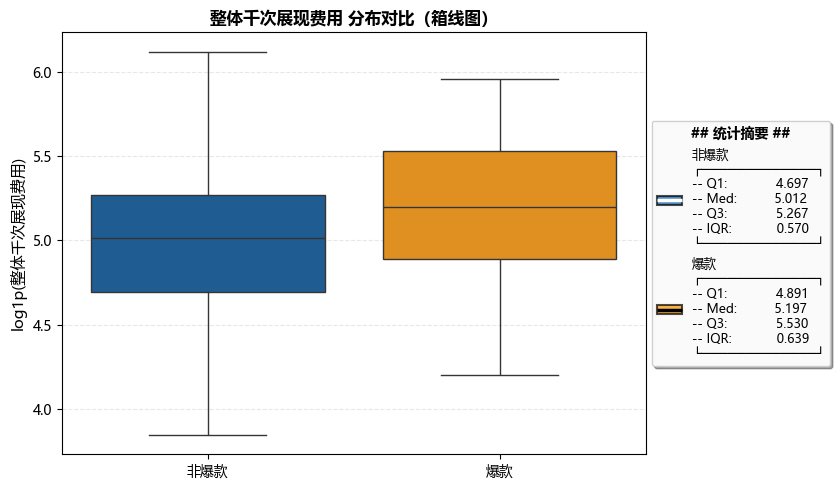

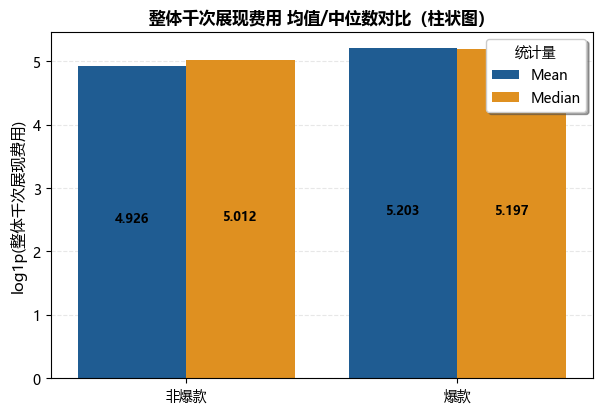

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_整体千次展现费用.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_整体千次展现费用.png


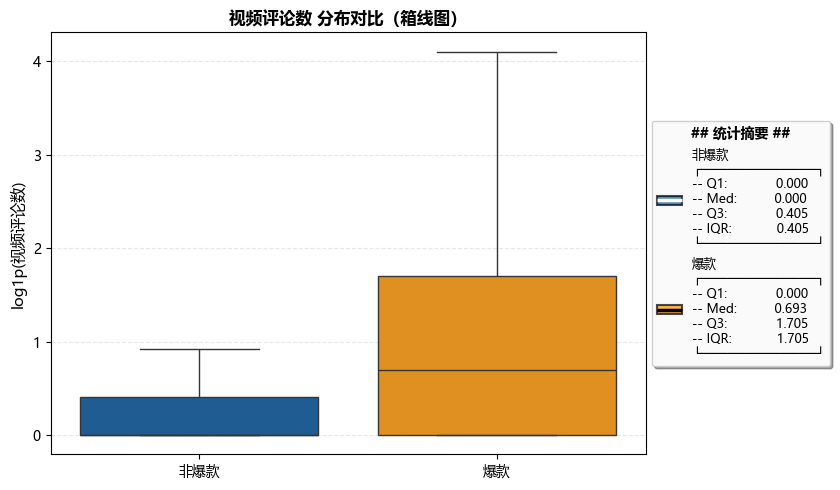

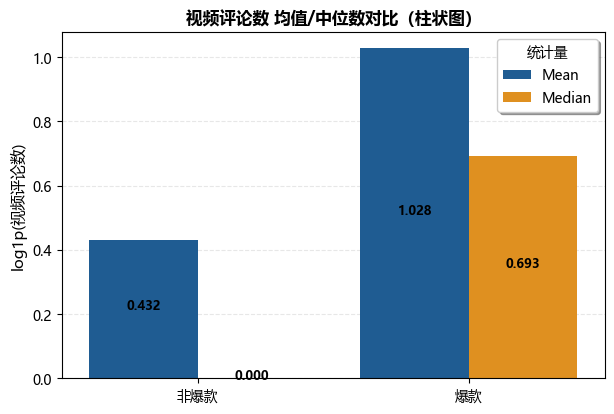

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_视频评论数.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_视频评论数.png


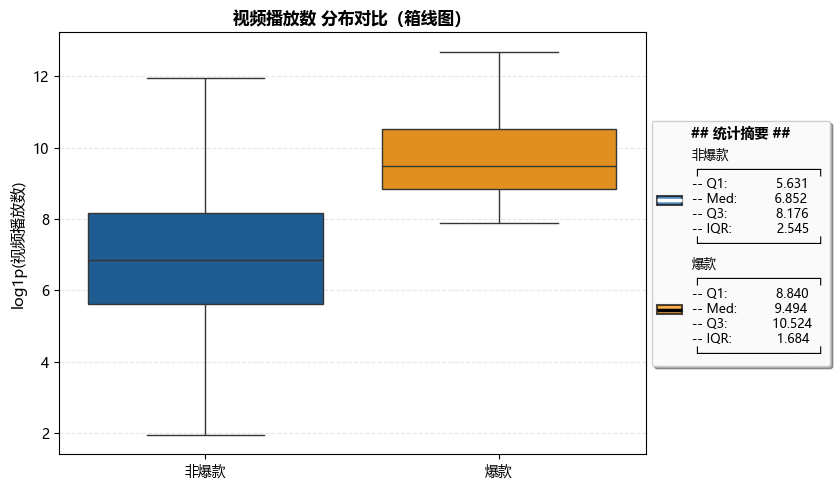

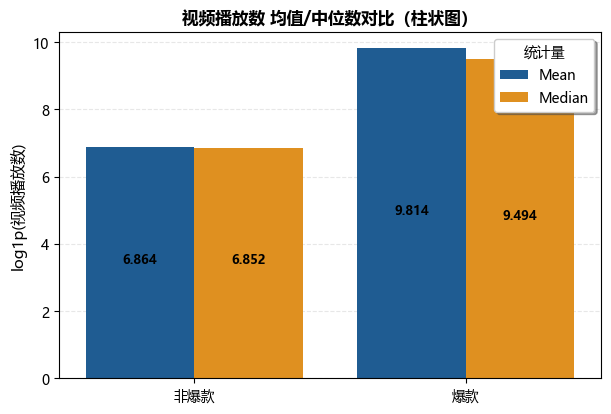

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_视频播放数.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_视频播放数.png


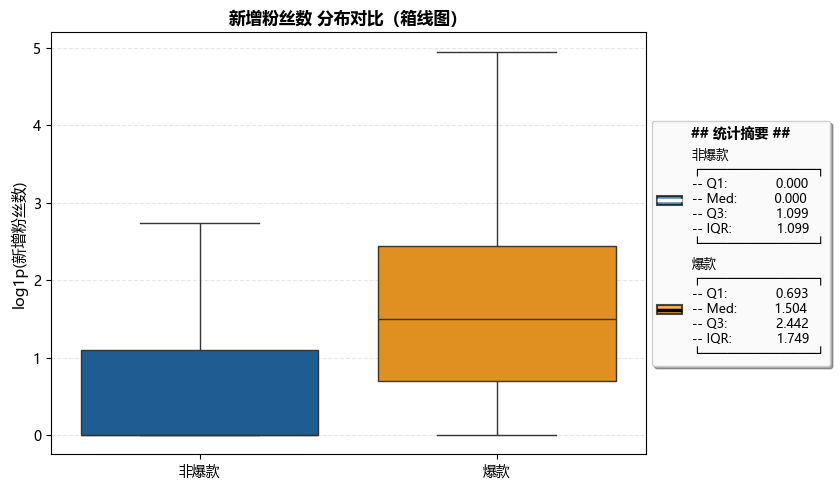

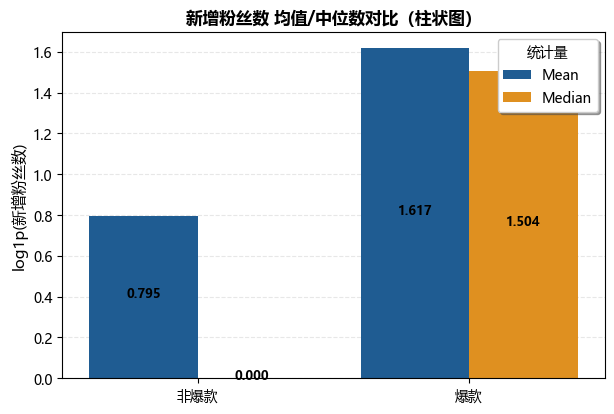

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_新增粉丝数.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_新增粉丝数.png


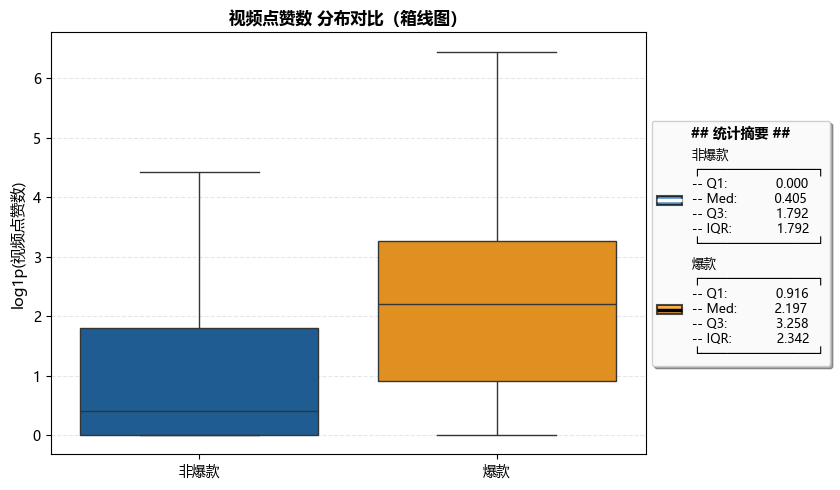

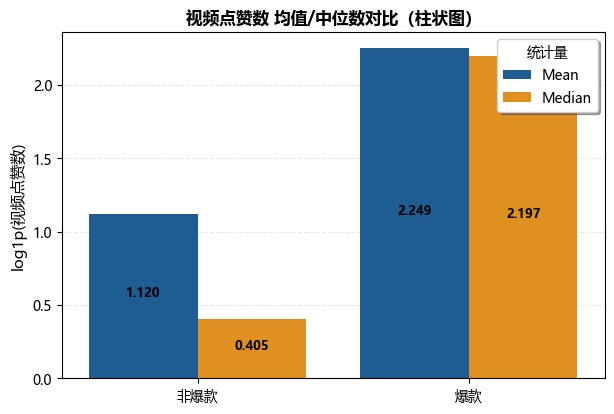

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_视频点赞数.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_视频点赞数.png


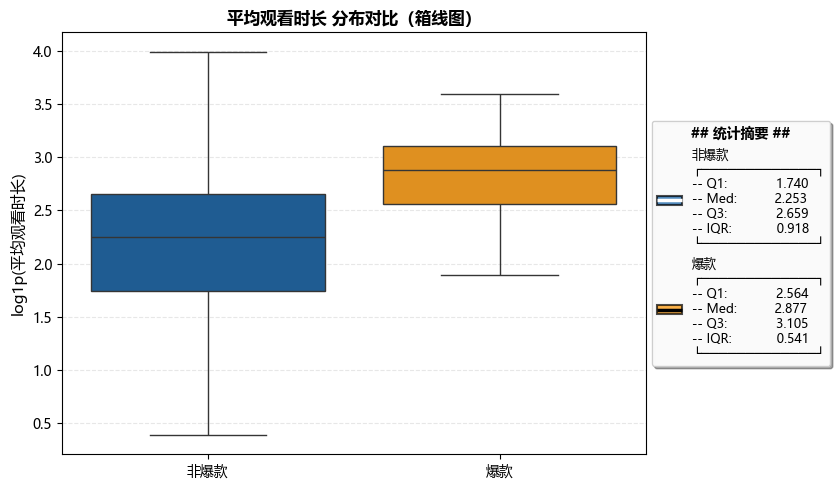

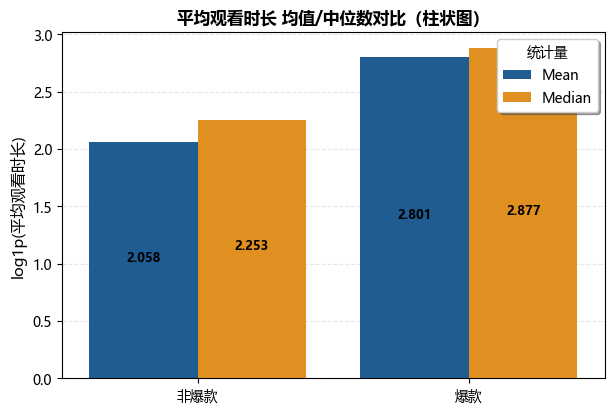

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_平均观看时长.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_平均观看时长.png


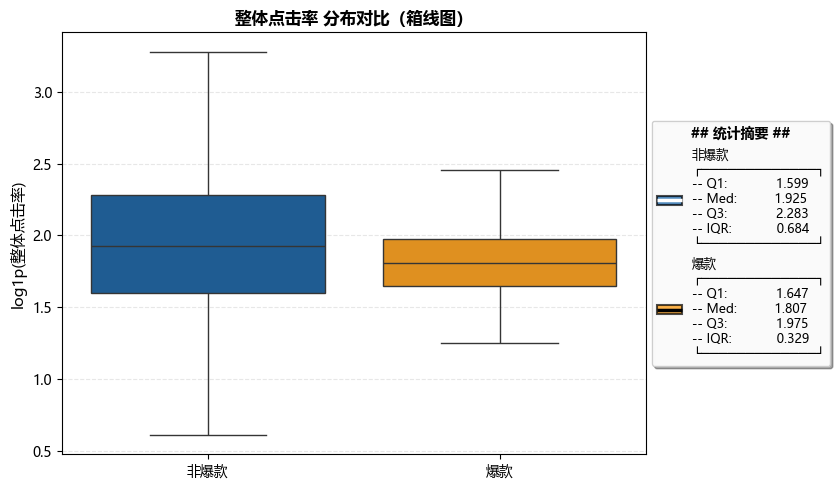

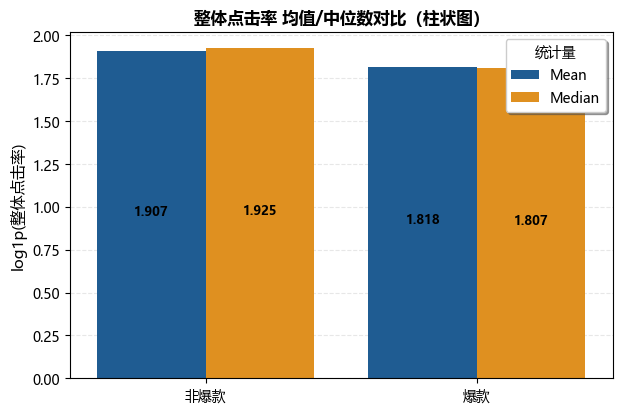

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_整体点击率.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_整体点击率.png


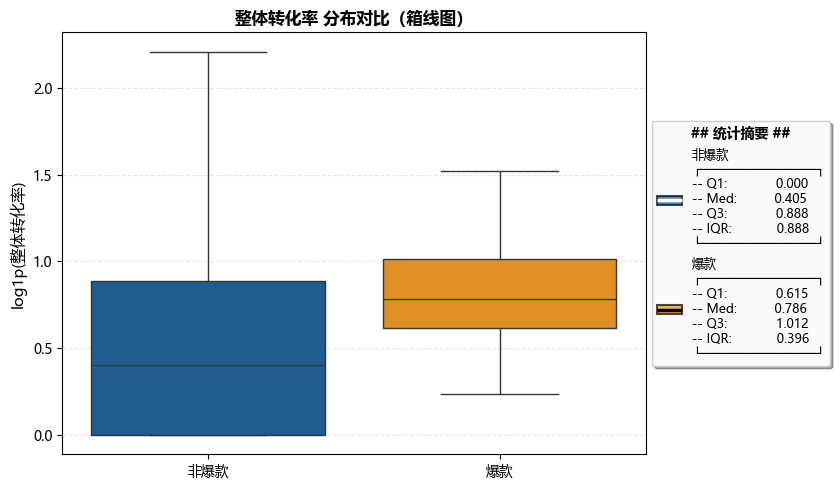

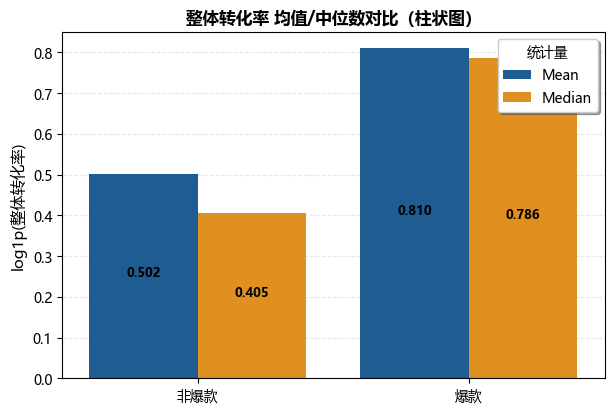

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_整体转化率.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_整体转化率.png


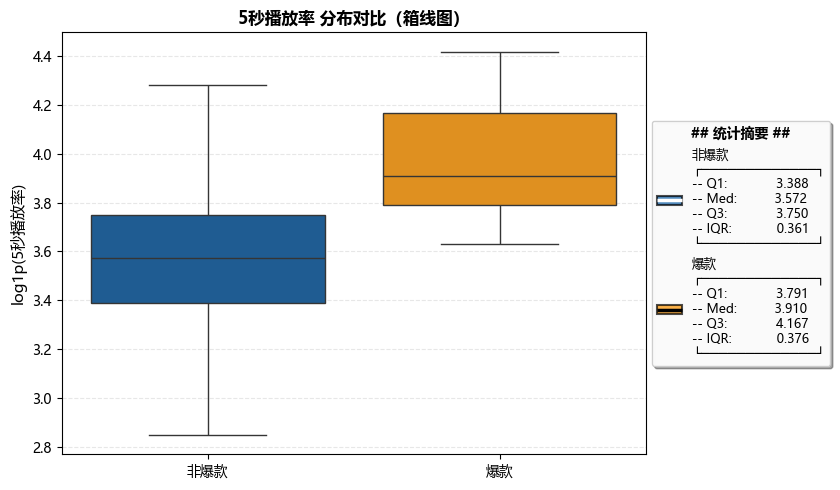

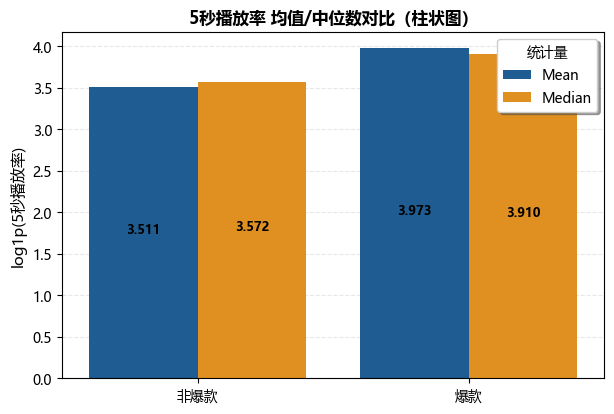

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_5秒播放率.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_5秒播放率.png


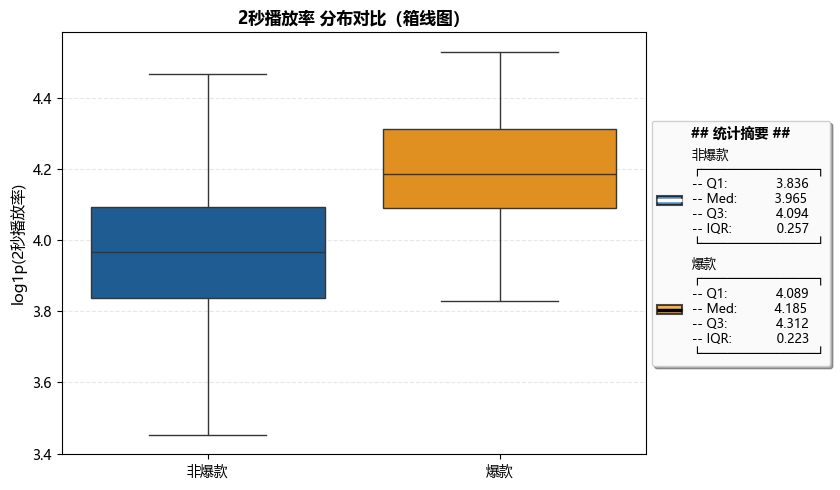

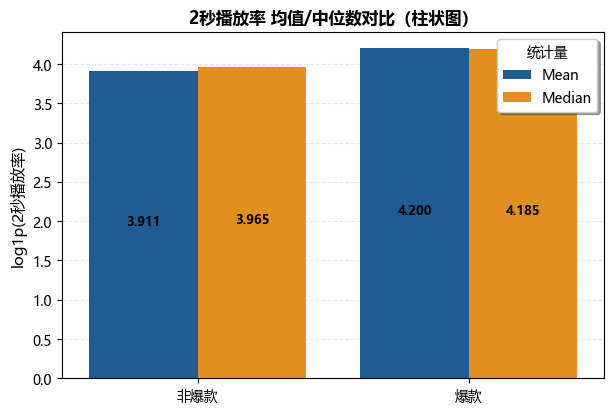

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_2秒播放率.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_2秒播放率.png


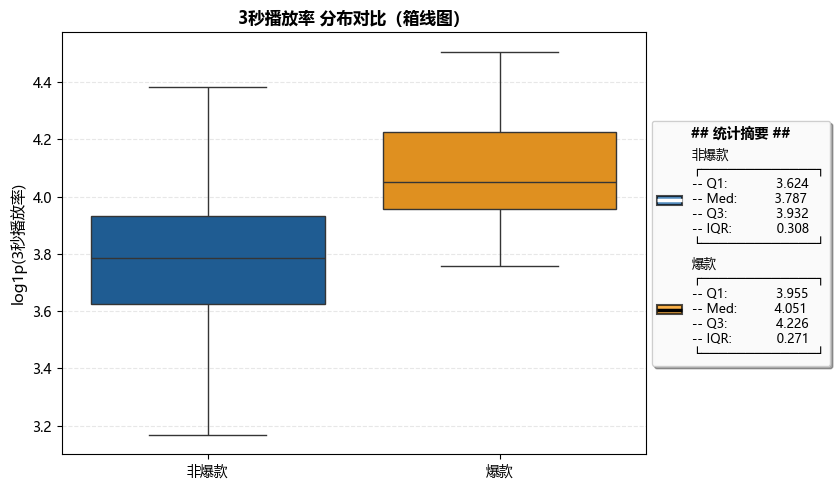

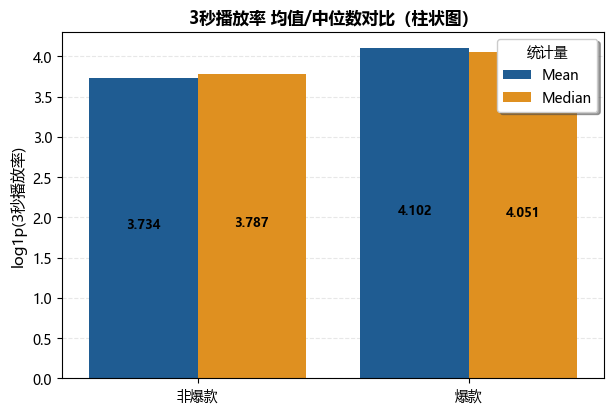

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_3秒播放率.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_3秒播放率.png


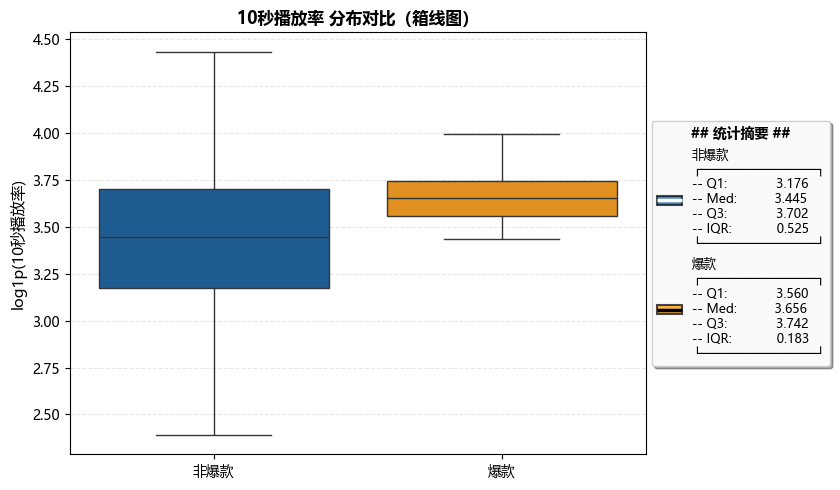

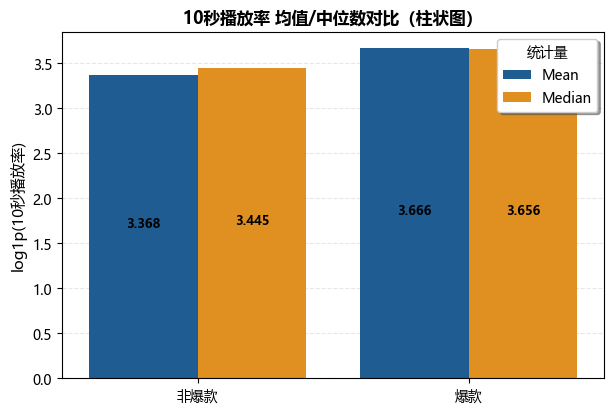

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_10秒播放率.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_10秒播放率.png


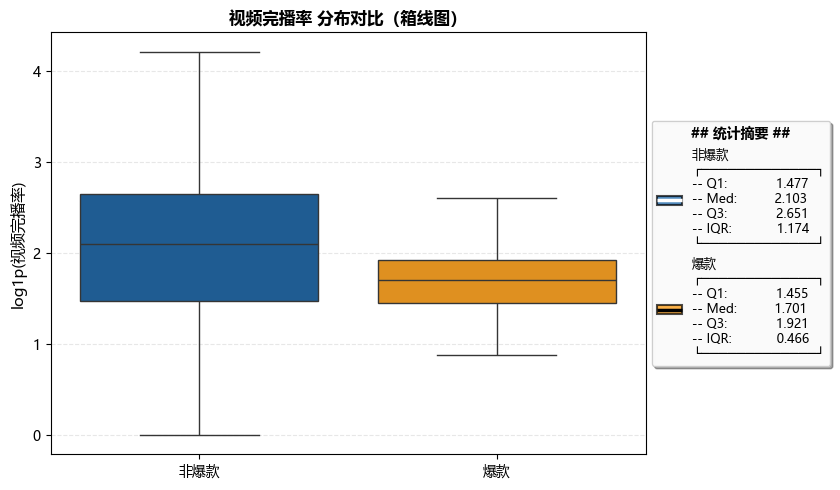

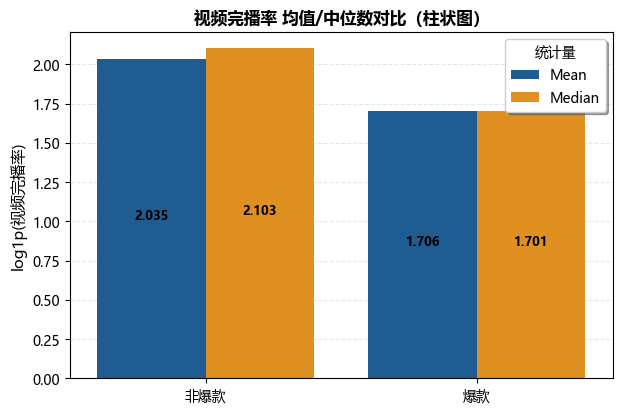

saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\box_视频完播率.png
saved: E:\Study\Tsinghua_Project\KINYO_Project\Deliverables\Mid-Term\Charts\bar_视频完播率.png


In [32]:
# 画图
for metric_c in metrics:
    plot_metric(df,metric_c, log1p=True)